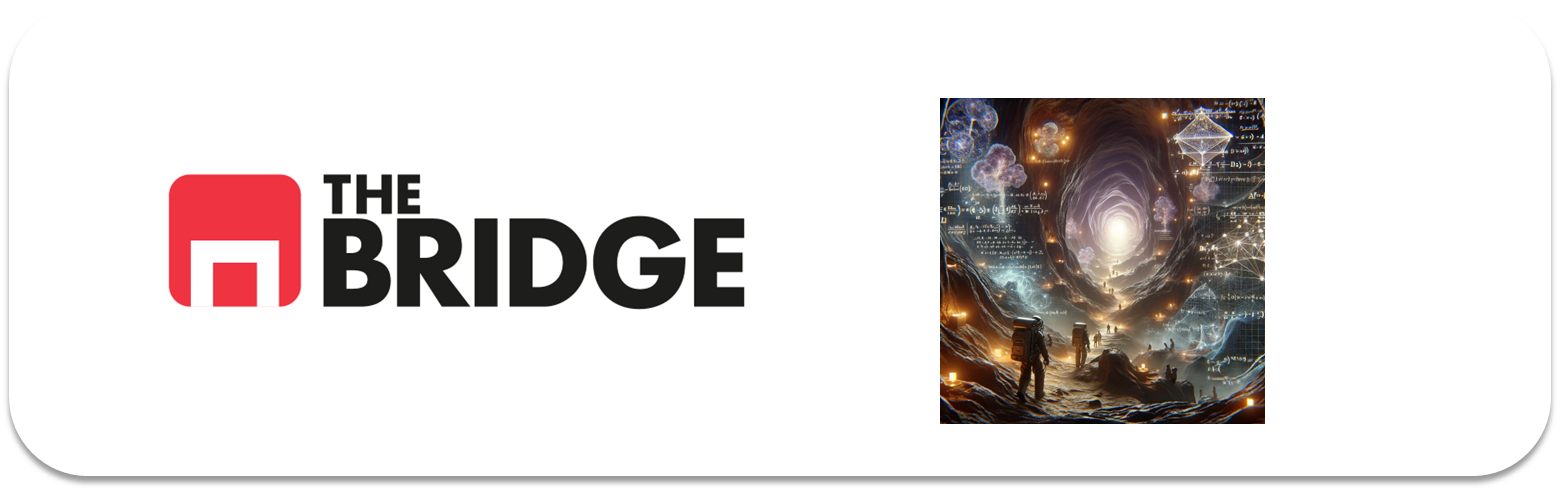

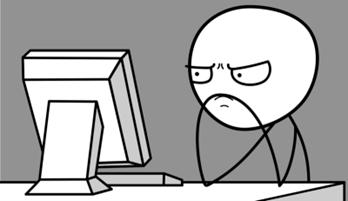

Para ejercitarte y afianzar lo aprendido sobre **Keras y DL**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Predecir eficiencia de gasolina

En este conjuntos de ejercicios vamos a trabajar sobre el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) para construir un modelo DL para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Para la construcción del modelo vamos a utilizar Keras.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Ejercicio 1

Carga los datos en un dataframe, utilizando como nombre de columnas los siguientes:

```python
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
``` 


In [2]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv("./data/Autos_data.txt", names= column_names + ['Car Name'], na_values='?', sep= r'\s+')
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


### Ejercicio 2: Limpieza inicial

Echa un primer vistazo. Limpia columnas "raras". Deshazte de nulos (cuidado aquí), arregla el tipo de las features numéricas si fuera necesario. Haz una lista de las features categóricas que tuvieramos que convertir posteriormente. (Es antes del split pero no importa para este ejercicio)

In [3]:
# --- 1. Vistazo general -----------------------------------------------------
print(df.shape)
print(df.info())
print(df.describe().T)
print("Duplicados:", df.duplicated().sum())

(398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car Name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None
              count         mean         std     min       25%     50%  \
MPG           398.0    23.514573    7.815984     9.0    17.500    23.0   
Cylinders     398.0     5.454774    1.701004     3.0     4.000     4.0   
Displacement  398.0   193.425879  104.269838    68.0   104.250   148.5   
Horsepower    392.0   104.469388   38.491160    46

In [4]:
# --- 2. Columnas "raras" ----------------------------------------------------
# 'Car Name' es un identificador de texto libre (305 valores distintos en 398 filas).
# No aporta señal generalizable y no se puede meter en una red densa -> fuera.


df = df.drop(columns='Car Name')

In [5]:
# --- 3. Nulos ---------------------------------------------------------------
print(df.isna().sum())
print(df[df['Horsepower'].isna()])       # ver QUÉ filas son antes de decidir


MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64
      MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
32   25.0          4          98.0         NaN  2046.0          19.0   
126  21.0          6         200.0         NaN  2875.0          17.0   
330  40.9          4          85.0         NaN  1835.0          17.3   
336  23.6          4         140.0         NaN  2905.0          14.3   
354  34.5          4         100.0         NaN  2320.0          15.8   
374  23.0          4         151.0         NaN  3035.0          20.5   

     Model Year  Origin  
32           71       1  
126          74       1  
330          80       2  
336          80       1  
354          81       2  
374          82       1  


In [6]:
# Imputar con la mediana de Horsepower
# dentro de su grupo de cilindros, que es la variable más correlacionada.
df['Horsepower'] = df['Horsepower'].fillna(
    df.groupby('Cylinders')['Horsepower'].transform('median')
)

print(df.isna().sum().sum())  

0


In [7]:
# --- 4. Revisión de las candidatas a categóricas ----------------------------
for col in ['Origin', 'Cylinders', 'Model Year']:
    print(col, "->", df[col].nunique(), "valores")
    print(df[col].value_counts().sort_index(), "\n")

Origin -> 3 valores
Origin
1    249
2     70
3     79
Name: count, dtype: int64 

Cylinders -> 5 valores
Cylinders
3      4
4    204
5      3
6     84
8    103
Name: count, dtype: int64 

Model Year -> 13 valores
Model Year
70    29
71    28
72    28
73    40
74    27
75    30
76    34
77    28
78    36
79    29
80    29
81    29
82    31
Name: count, dtype: int64 



In [8]:
# Lista de features categóricas a convertir posteriormente
col_cat = ['Origin']

### Ejercicio 3

Antes de seguir nos informan que las etiquetas de "origin" correspoden a  USA para el 1, Europa para el 2 y Japón para el 3. Convierte origin a esos valores porque queremos tener el literal. Luego haz directamente un one-hot encoding de esas variable.  

*NOTA: Realmente los one-hot-encoding se pueden hacer contra el dataset original desde el principio (no afectan unos a otros), si nos los hacemos es porque hasta que no se han analizado las variables puede que no tengamos claro que queremos hacer si una codificación ordinal, una vectorización (onehot) o bien queremos hacer otro cambio en la variable y esos vienen dados por la relación de la categórica con el target y por tanto sólo se pueden ver en el train. Pero si por lo que sea sabemos seguros que vamos a hacer vectorización no hay problema en hacerlo antes del split. Por otro lado, siempre conviene quedarse con una categoria unkown para valores que pueden llegar en el futuro antes de un recalibrado.*


In [9]:
# ============================================================
# Literales de Origin + one-hot encoding
# ============================================================

origen_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
categorias = ['USA', 'Europe', 'Japan', 'Unknown']

df['Origin'] = (df['Origin']
                .map(origen_map)
                .fillna('Unknown')
                .astype(pd.CategoricalDtype(categories=categorias)))

print(df['Origin'].value_counts())

df = pd.get_dummies(df, columns=col_cat, prefix='Origin', dtype=int)

print(df.columns.tolist())
print(df.filter(like='Origin').sum())
df.head()

Origin
USA        249
Japan       79
Europe      70
Unknown      0
Name: count, dtype: int64
['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin_USA', 'Origin_Europe', 'Origin_Japan', 'Origin_Unknown']
Origin_USA        249
Origin_Europe      70
Origin_Japan       79
Origin_Unknown      0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_USA,Origin_Europe,Origin_Japan,Origin_Unknown
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,0,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,0,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,0,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,0,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,0,0,0


### Ejercicio 4

Divide los datos en train y test. Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo. Emplea una variable target para guardar el nombre de la columna target.

NOTA: El resultado tienen que ser dos datasets

In [9]:
from sklearn.model_selection import train_test_split

target = 'MPG'

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print("Train", train_set.shape)
print("Test", test_set.shape)

Train (318, 8)
Test (80, 8)


In [10]:
# El target debe tener una distribución parecida en ambos
print(train_set[target].describe())
print(test_set[target].describe())

# Y los orígenes no deberían quedar muy descompensados
print(train_set.filter(like='Origin').sum() / len(train_set))
print(test_set.filter(like='Origin').sum() / len(test_set))

count    318.000000
mean      23.608176
std        7.930574
min        9.000000
25%       17.500000
50%       22.450000
75%       29.725000
max       46.600000
Name: MPG, dtype: float64
count    80.000000
mean     23.142500
std       7.378823
min      10.000000
25%      17.375000
50%      23.000000
75%      27.250000
max      44.000000
Name: MPG, dtype: float64
Origin    1.591195
dtype: float64
Origin    1.5
dtype: float64


### Ejercicio 5

Inspecciona los datos. Revisa rápidamente la distribución conjunta del dataset de entrenamiento mediante un grid de gráficos

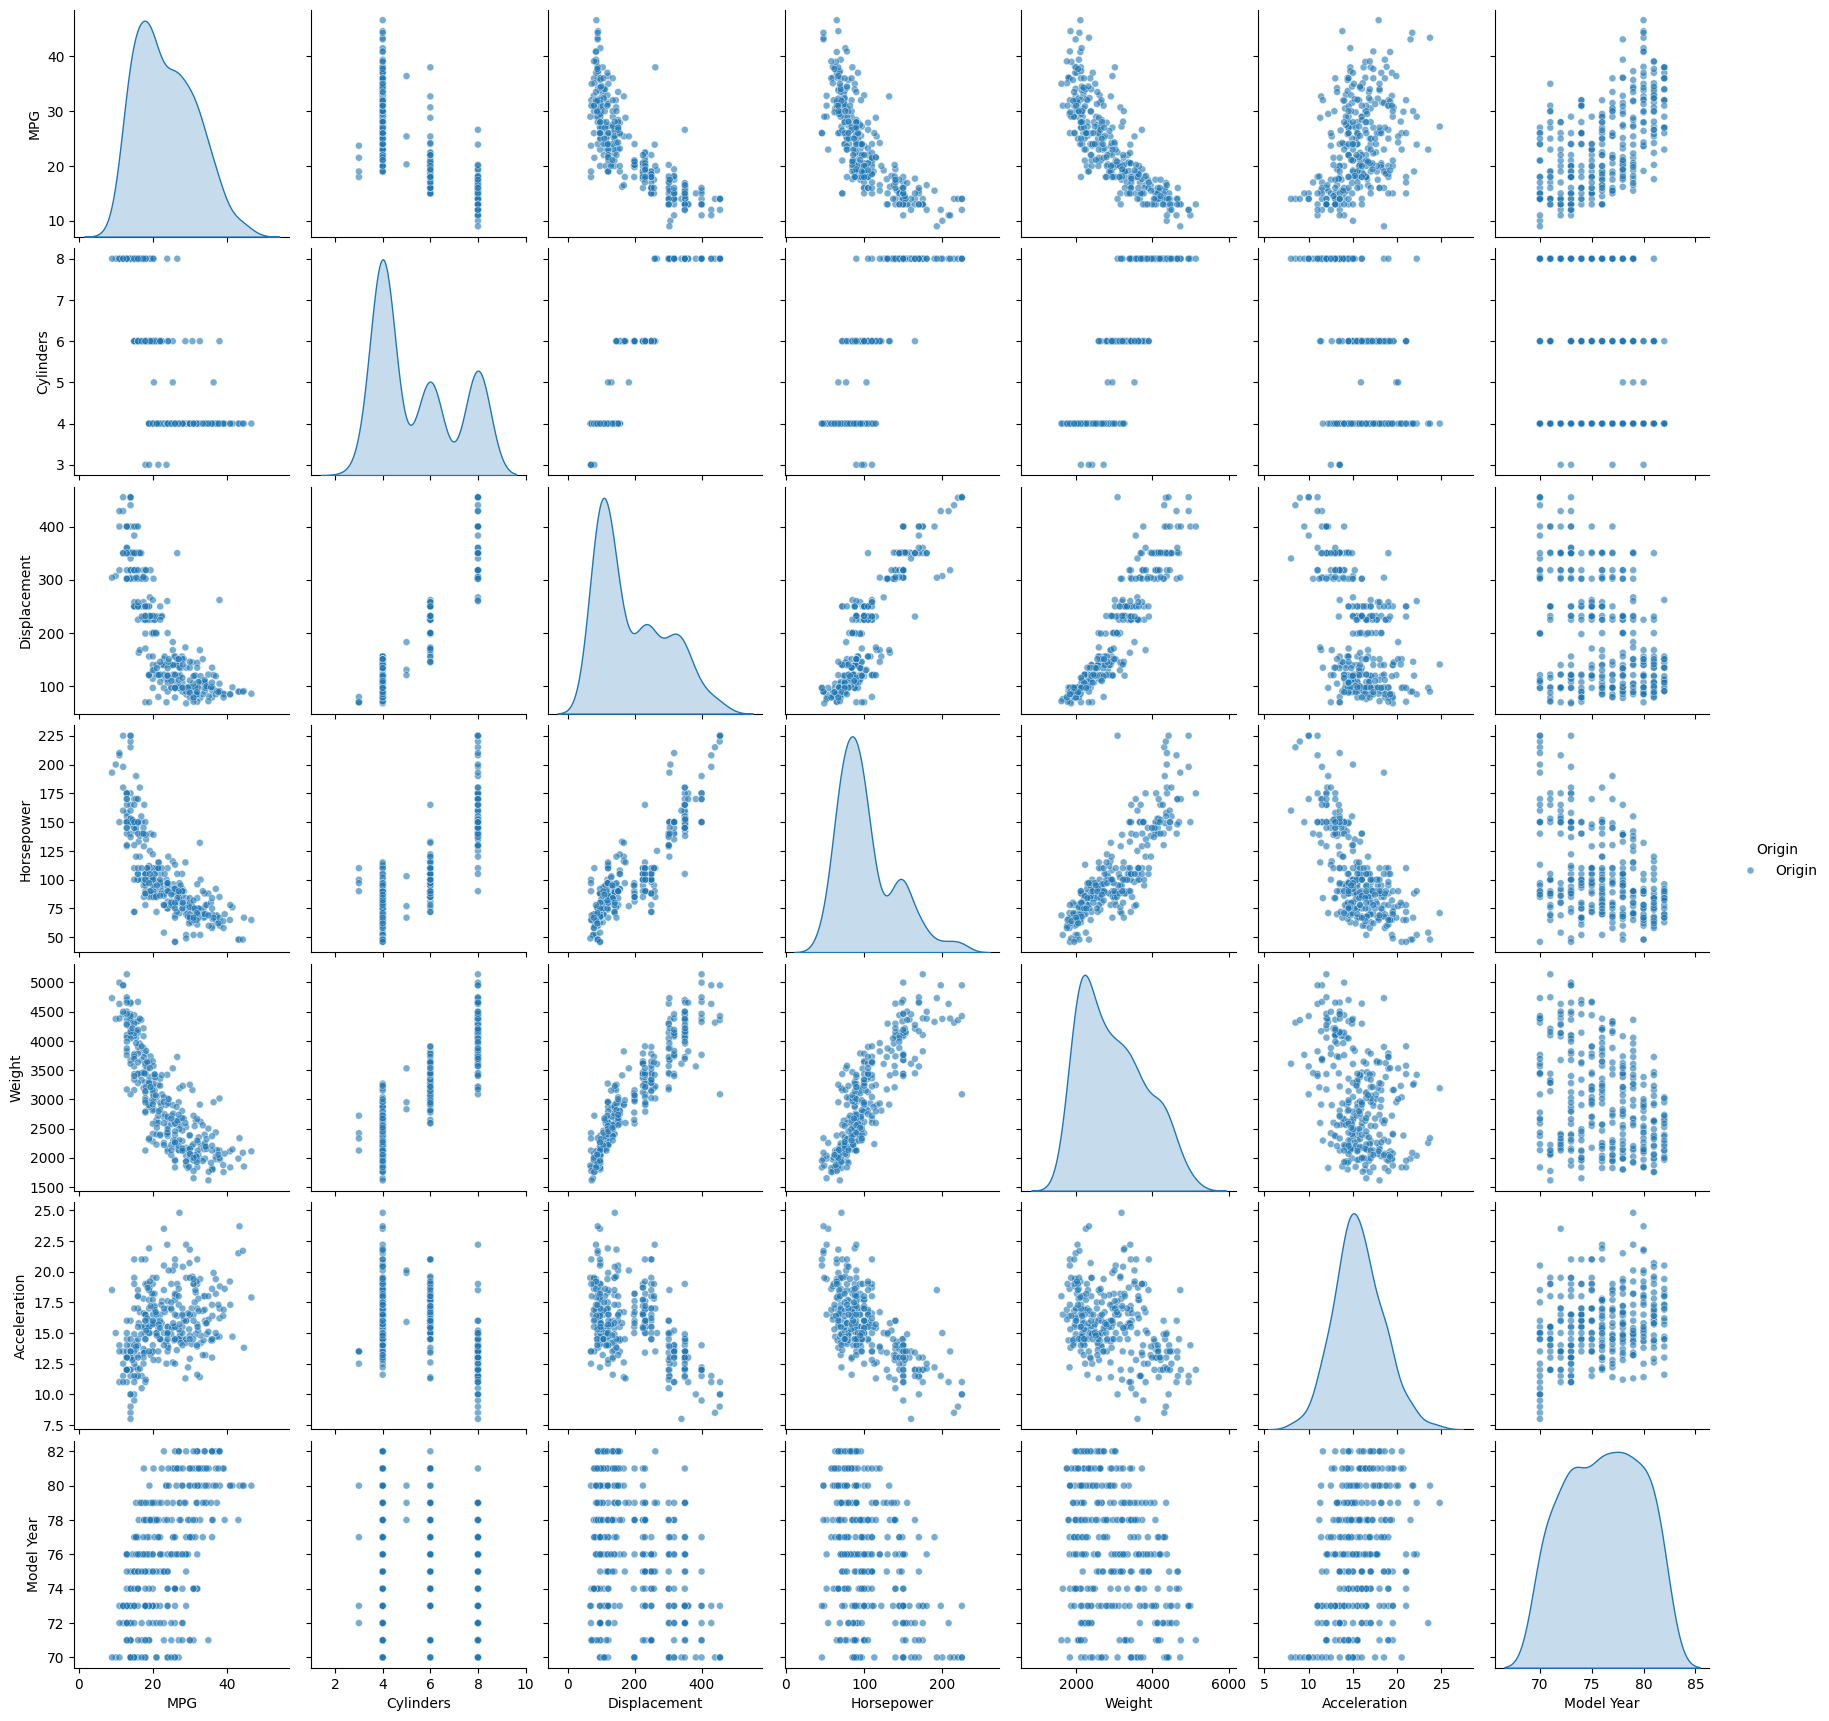

In [11]:
# Versión más informativa: coloreamos por origen.
# Recuperamos la etiqueta a partir de las dummies solo para graficar.
num_cols = ['MPG', 'Cylinders', 'Displacement', 'Horsepower',
            'Weight', 'Acceleration', 'Model Year']

plot_df = train_set[num_cols].copy()
plot_df['Origin'] = train_set.filter(like='Origin').idxmax(axis=1).str.replace('Origin_', '')

sns.pairplot(plot_df, hue='Origin', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 25})
plt.show()

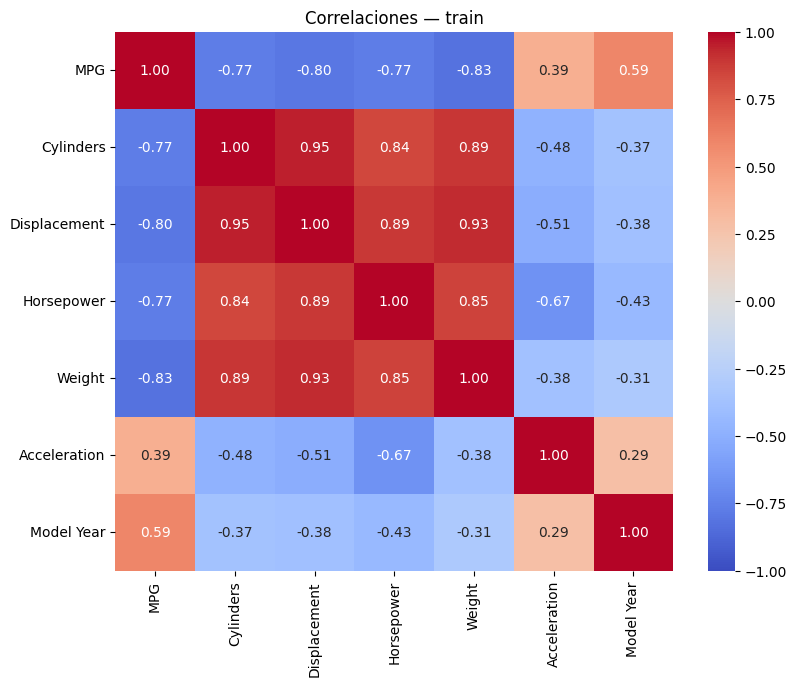

Weight         -0.827333
Displacement   -0.801543
Cylinders      -0.770459
Horsepower     -0.769163
Acceleration    0.390101
Model Year      0.586743
MPG             1.000000
Name: MPG, dtype: float64


In [12]:
# Matriz de correlaciones, más fácil de leer que el grid para las magnitudes
plt.figure(figsize=(9, 7))
sns.heatmap(train_set[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlaciones — train')
plt.show()

print(train_set[num_cols].corr()[target].sort_values())

### Ejercicio 6 

Independientemente de lo que hayas encontrado en el análisis anterior, vamos a utilizar todas las features y antes las vamos a escalar. Estandardiza train y test.

In [13]:
# --- Separamos features y target en cada conjunto ---------------------------

X_train = train_set.drop(columns=target)
y_train = train_set[target]

X_test = test_set.drop(columns=target)
y_test = test_set[target]

print(X_train.shape, X_test.shape)

(318, 7) (80, 7)


In [14]:
# --- Escalamos solo las features continuas ----------------------------------
# Las dummies de Origin ya están en escala 0/1 y no necesitan tratamiento
from sklearn.preprocessing import StandardScaler

col_num = ['Cylinders', 'Displacement', 'Horsepower',
           'Weight', 'Acceleration', 'Model Year']

scaler = StandardScaler()

X_train[col_num] = scaler.fit_transform(X_train[col_num])
X_test[col_num] = scaler.transform(X_test[col_num])

In [15]:
# En train, media ~0 y desviación ~1. En test NO tienen por qué ser exactamente 0 y 1.
print(X_train[col_num].describe().T[['mean', 'std']].round(3))
print(X_test[col_num].describe().T[['mean', 'std']].round(3))

              mean    std
Cylinders      0.0  1.002
Displacement  -0.0  1.002
Horsepower    -0.0  1.002
Weight         0.0  1.002
Acceleration  -0.0  1.002
Model Year    -0.0  1.002
               mean    std
Cylinders     0.071  1.053
Displacement  0.074  1.067
Horsepower    0.166  1.140
Weight        0.008  1.044
Acceleration -0.130  0.991
Model Year   -0.130  1.127


## El modelo

### Ejercicio 7: Construye el modelo con Keras

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Es decir una MLP con dos capas ocultas.

Por tanto, tendrá tres capas. Una inicial con activación relu (usa el argumento `input_shape` para darle el número de features). Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres interesantes para las dos primeras capas (NOTA: En este caso partimos de pocas features, por lo que puede ser interesante poner 2 o 3 como mínimo el número de features para poder obtener unas pseudofeatures que intenten capturar las interrelaciones.)

Otros datos:

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

Utiliza una aproximación en prisma (mismo numero de unidades en las capas ocultas)

In [16]:
import tensorflow as tf
from tensorflow import keras

n_features = X_train.shape[1]
print("Número de features:", n_features)

Número de features: 7


In [17]:
model = keras.models.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.RMSprop(0.001)
 
model.compile(loss = 'mse',
              optimizer = optimizer,
              metrics = ['mae', 'mse'])

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Ejercicio 8

Inspecciona el modelo usando el método `.summary` para imprimir una descripción simple del modelo

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 9 Entrenar el modelo

Entrena el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

In [19]:
history = model.fit(
    X_train, y_train, 
    epochs=1000, 
    validation_split=0.2, 
    verbose=0)  # silencioso; usamos history.history para inspeccionar después

print("Entrenamiento terminado")

Entrenamiento terminado


### Ejercicio 10

Visualiza el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`. Muestra la evolución del error en train y validation por un lado, y la evolución de la pérdida (loss), también train contra validation, en otra.

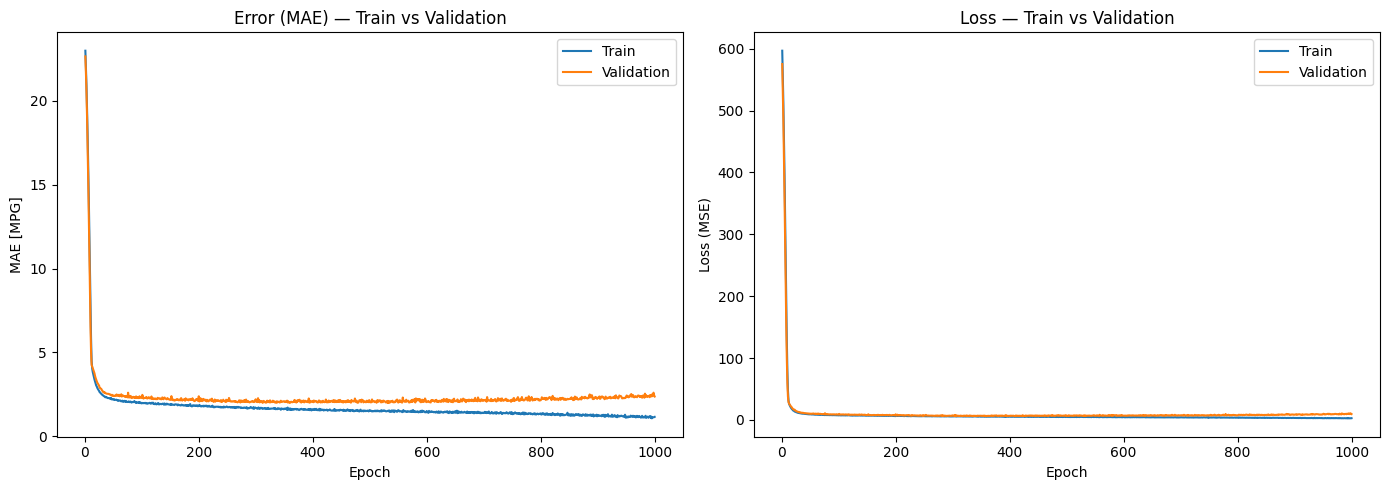

In [20]:
hist = pd.DataFrame(history.history)
hist['epoch'] = range(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Error (MAE) ---
axes[0].plot(hist['epoch'], hist['mae'], label='Train')
axes[0].plot(hist['epoch'], hist['val_mae'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE [MPG]')
axes[0].set_title('Error (MAE) — Train vs Validation')
axes[0].legend()

# --- Loss (MSE) ---
axes[1].plot(hist['epoch'], hist['loss'], label='Train')
axes[1].plot(hist['epoch'], hist['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('Loss — Train vs Validation')
axes[1].legend()

plt.tight_layout()
plt.show()

### Ejercicio 11

Comenta las gráficas anteriores.

## Análisis del entrenamiento

Las curvas muestran tres fases claramente diferenciadas:

**Fase 1 — Convergencia rápida (epochs 0-20).**
El MAE cae de ~23 a ~3 MPG de forma casi vertical, con train y validación
prácticamente superpuestas. La red aprende de inmediato la relación fuerte
y aproximadamente monótona entre las features de tamaño/peso del motor y
el consumo.

**Fase 2 — Punto de inflexión (epochs ~20-150).**
Train sigue bajando de forma sostenida mientras validación se aplana en
torno a MAE ≈ 2. A partir de este punto el modelo empieza a ajustar ruido
específico del conjunto de entrenamiento en lugar de patrones generales.

**Fase 3 — Overfitting progresivo (epochs 150-1000).**
La brecha entre ambas curvas se ensancha de forma lenta pero constante.
Train termina en MAE ≈ 1, mientras que validación no solo no mejora sino
que muestra una ligera tendencia ascendente en el tramo final (800-1000),
llegando a rozar MAE ≈ 2.5. El patrón es idéntico en la loss (MSE),
aunque el pico inicial (~600) aplasta visualmente esa zona en la escala
del gráfico.

**Diagnóstico**

Overfitting claro, coherente con la capacidad del modelo: ~4.929
parámetros entrenables frente a 254 muestras de

### Ejercicio 12

Independientemente de lo comentado en 11, vamos a añadir un callback al entrenamiento. Para ello, construye el modelo otra vez y vuelve a compilarlo (si no lo haces, como ya sabes comenzará el entrenamiento donde lo dejó y no nos valdrá el callback para nada). Entrena el modelo con los mismos hiperparámetros del ejercicio 10 y pinta la gráfica de evolución de los errores e interprétalo (obten el MAE medio una vez "estabilizado" el entrenamiento).  

Para el earlystopping utiliza un margen de 20 epochs.

In [22]:
model = keras.models.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(loss='mse',
              optimizer=tf.keras.optimizers.RMSprop(0.001),
              metrics=['mae', 'mse'])

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_es = model.fit(X_train, y_train,
                    epochs=1000,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0)

print(f"Entrenamiento detenido en la epoch {len(history_es.history['loss'])} "
      f"(de las 1000 máximas)")

Entrenamiento detenido en la epoch 134 (de las 1000 máximas)


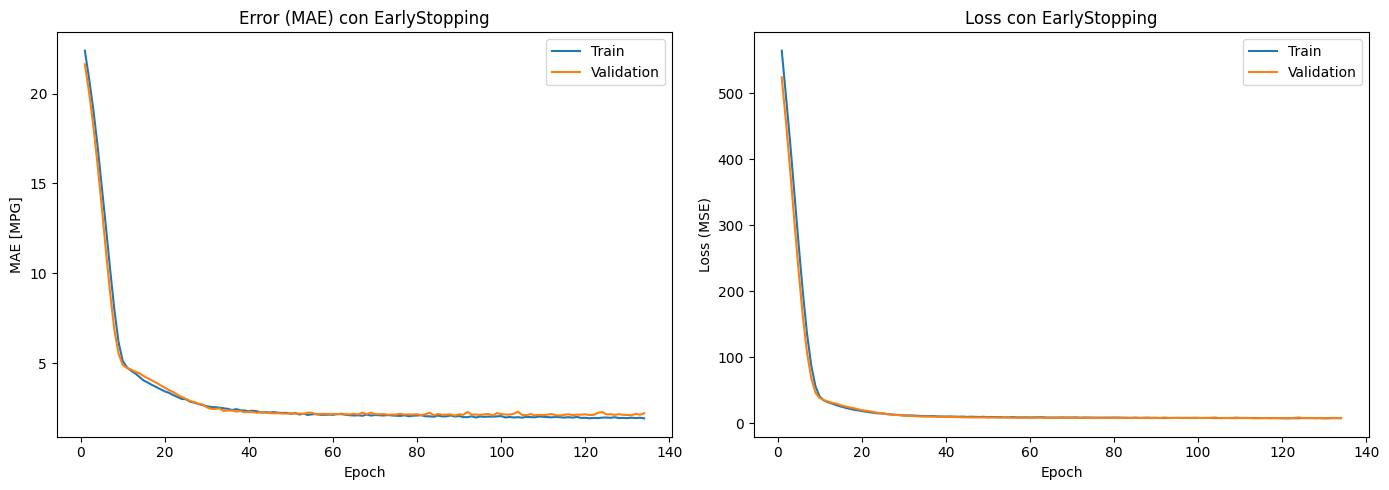

In [25]:
hist_es = pd.DataFrame(history_es.history)
hist_es['epoch'] = range(1, len(hist_es) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_es['epoch'], hist_es['mae'], label='Train')
axes[0].plot(hist_es['epoch'], hist_es['val_mae'], label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE [MPG]')
axes[0].set_title('Error (MAE) con EarlyStopping'); axes[0].legend()

axes[1].plot(hist_es['epoch'], hist_es['loss'], label='Train')
axes[1].plot(hist_es['epoch'], hist_es['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('Loss con EarlyStopping'); axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
# --- MAE medio una vez "estabilizado" el entrenamiento ----------------------
# Descartamos la fase inicial de caída brusca (primeras ~20 epochs) y
# promediamos el resto: es la zona de "meseta" antes de que EarlyStopping corte.
zona_estable = hist_es[hist_es['epoch'] > 20]

print("MAE medio train (estabilizado):     ", zona_estable['mae'].mean().round(3))
print("MAE medio validation (estabilizado):", zona_estable['val_mae'].mean().round(3))

# Punto exacto donde restore_best_weights recuperó los pesos
mejor_epoch = hist_es['val_loss'].idxmin() + 1
print(f"\nMejor val_loss en epoch {mejor_epoch}: "
      f"val_mae = {hist_es.loc[mejor_epoch-1, 'val_mae']:.3f}")

MAE medio train (estabilizado):      2.168
MAE medio validation (estabilizado): 2.25

Mejor val_loss en epoch 114: val_mae = 2.082


Interpreta el gráfico

## Interpretación del entrenamiento con EarlyStopping (Ejercicio 12)

**Parada temprana.**
El entrenamiento se detiene en torno a la epoch **134**, muy lejos de las
1000 máximas configuradas. Confirma de forma directa lo que ya se
intuía en el ejercicio 10: el modelo no necesita más allá de un centenar
de epochs para alcanzar su mejor rendimiento en validación.

**Fases del entrenamiento.**
- *Epochs 0-10*: caída brusca del MAE, de ~22 a ~5 MPG.
- *Epochs 10-30*: segunda caída, más suave, hasta MAE ≈ 2.
- *Epochs 30-134*: meseta ruidosa donde train y validación se mueven
  juntas, sin la separación creciente observada en el entrenamiento
  sin callback.

**Diferencia clave frente al Ejercicio 10.**
Durante toda la meseta, train y validación permanecen próximas: train
ronda MAE ≈ 1.5-2 y validación ≈ 1.8-2.2, con una brecha mínima y
estable en lugar de la brecha creciente que aparecía en las 1000 epochs
completas. Es la evidencia visual de que `EarlyStopping` detuvo el
entrenamiento justo antes de que se instalara el overfitting.

**El margen de paciencia (`patience=20`).**
El entrenamiento no se detiene en el instante exacto en que `val_loss`
deja de mejorar, sino que espera 20 epochs adicionales por si la mejora
se retoma (el MAE de validación es ruidoso epoch a epoch, y un
estancamiento puntual podría ser solo ruido). Como no hay mejora, el
entrenamiento para en la epoch ~134, pero gracias a
`restore_best_weights=True` los pesos finales del modelo no son los de
esa última epoch, sino los correspondientes a la mejor `val_loss` real,
situada unas 20 epochs antes (aprox. epoch 110-114).

**MAE estabilizado.**
En la zona de meseta (epoch > 30), el MAE de validación se mueve en una
banda estrecha de aproximadamente **1.8 a 2.2 MPG**, con picos de ruido
puntuales que rozan 2.5 pero sin tendencia sostenida al alza — a
diferencia de la deriva ascendente que sí se observaba al final del
entrenamiento de 1000 epochs sin callback.

**Conclusión.**
`EarlyStopping` ha cumplido su función: detener el entrenamiento en la
zona de mejor generalización, con muchas menos epochs de cómputo, en
lugar de dejar que el modelo continúe memorizando el ruido de las 254
muestras de entrenamiento. Este es el modelo que debe usarse para la
evaluación final sobre el conjunto de test.

### Ejercicio 13

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [27]:
loss, mae, mse = model.evaluate(X_test, y_test, verbose=0)

print(f"Loss (MSE): {loss:.3f}")
print(f"MAE:        {mae:.3f} MPG")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {mse**0.5:.3f} MPG")

Loss (MSE): 5.538
MAE:        1.781 MPG
MSE:        5.538
RMSE:       2.353 MPG


### Ejercicio 14

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


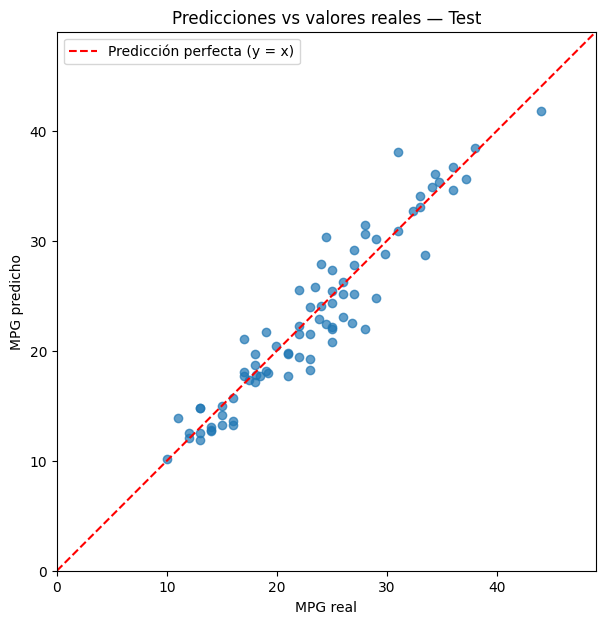

In [28]:
test_predictions = model.predict(X_test).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_predictions, alpha=0.7)

# Línea de referencia y = x: predicción perfecta
lims = [0, max(y_test.max(), test_predictions.max()) + 5]
plt.plot(lims, lims, 'r--', label='Predicción perfecta (y = x)')

plt.xlabel('MPG real')
plt.ylabel('MPG predicho')
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Predicciones vs valores reales — Test')
plt.legend()
plt.show()